load data

In [1]:
from pathlib import Path
from typing import Literal

import torch

from collections.abc import Callable

from datasets import Dataset, load_dataset, load_from_disk
from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)

import evaluate
import glob
import json
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from pathlib import Path
from datetime import datetime

import sys

sys.path.insert(0, str(Path.cwd().parent))


from finetuning.commons import PipelineData, prepare_data, parse_pubtator, build_training_samples, samples_to_rels_like_df
from dataset_preparation.perturbations import BIORED_RELATION_TYPES, NO_RELATION_LABEL
from dataset_preparation.prepare_pure_biored import build_pure_biored_samples, compute_relation_distance_stats

/home/flabonte/Unsloth_RL/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
PUBTATOR_FILE_TRAIN = "/home/flabonte/LLMs_for_NEL/Data/BioRED/Train.PubTator"
PUBTATOR_FILE_TEST = "/home/flabonte/LLMs_for_NEL/Data/BioRED/Test.PubTator"
PUBTATOR_FILE_DEV = "/home/flabonte/LLMs_for_NEL/Data/BioRED/Dev.PubTator"

CACHE_DIR = Path("cache")
BATCH_SIZE = 32
NUM_PROCS = 32
USE_CACHE = True

DATASET_NAME: Literal["BioRed", "BioRedPerturbated"] = "BioRed"
RELATION_LABELS: list[str] = BIORED_RELATION_TYPES + [NO_RELATION_LABEL]
label2id: dict[str, int] = {name: idx for idx, name in enumerate(RELATION_LABELS)}
id2label: dict[int, str] = {idx: name for name, idx in label2id.items()}
MASK_TOKEN = "[MASK]"

In [ ]:


def build_samples(
    pubtator_file: Path,
    dataset_name: Literal["BioRed", "BioRedPerturbated"] = DATASET_NAME,
    label_map: dict[str, int] = label2id,
    mask_token: str = MASK_TOKEN,
    no_relation_label: str = NO_RELATION_LABEL,
    parsed: tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame] | None = None,
    distance_stats: dict[str, float] | None = None,
    verbose: bool = True,
    no_relation_ratio = 1 #this you can use to control how many no relation labels none = all
) -> pd.DataFrame:
    """Parse a PubTator file and build the relation-classification samples DataFrame.

    Args:
        pubtator_file: Path to the PubTator file to parse.
        dataset_name: Which sample-building strategy to use. ``"BioRed"`` uses gold
            relations plus distance-matched NoRelation examples, ``"BioRedPerturbated"``
            uses the perturbated training samples.
        label_map: Mapping from relation label name to integer class id.
        mask_token: Token used as the relation placeholder in the prompt.
        no_relation_label: Label assigned to ``false_positive`` (unrelated) pairs.
        parsed: Optional pre-parsed ``(meta, anns, rels)`` tuple to avoid re-reading the file.
        distance_stats: Train-fit distance thresholds for NoRelation sampling on dev/test.
        verbose: Whether to print NoRelation sampling diagnostics.

    Returns:
        A DataFrame with ``prompt``, ``target_relation`` and ``label`` columns,
        restricted to ``gold`` and ``false_positive`` perturbations.
    """
    if parsed is not None:
        meta_df, anns_df, rels_df = parsed
    else:
        meta_df, anns_df, rels_df = parse_pubtator(pubtator_file)

    if dataset_name == "BioRedPerturbated":
        samples = build_training_samples(meta_df, anns_df, rels_df)

    elif dataset_name == "BioRed":
        # Original BioRED: gold relations + distance-matched NoRelation examples.
        samples = build_pure_biored_samples(
            meta_df,
            anns_df,
            rels_df,
            distance_stats=distance_stats,
            verbose=verbose,
            no_relation_ratio= no_relation_ratio
        )

    else:
        raise ValueError(f"Unknown dataset_name: {dataset_name!r}")

    samples = samples_to_rels_like_df(samples)

    # Gold relations (8 types) + unrelated entity pairs (NoRelation).
    samples = samples[samples["perturbation"].isin(["gold", "false_positive"])].copy()

    samples["prompt"] = samples.apply(
        lambda row: (
            f"Relation: {row['entity_a_text']} -> {mask_token} -> {row['entity_b_text']}\n"
            f"Context: {row['abstract']}"
        ),
        axis=1,
    )
    samples["target_relation"] = np.where(
        samples["perturbation"] == "false_positive",
        no_relation_label,
        samples["relation_type"],
    )
    samples["label"] = samples["target_relation"].map(label_map)
    return samples

def load_or_cache(split: str, prefix: str, build: Callable[[], Dataset], use_cache: bool = True) -> Dataset:
    """Load a Hugging Face ``Dataset`` from disk cache or build and persist it.

    Cached data is stored under ``CACHE_DIR / f"{prefix}_{split}"`` (default: ``cache/``).
    On a cache hit, ``load_from_disk`` is used and ``build`` is not called.
    On a miss, ``build()`` runs once, the result is saved with ``save_to_disk``, then returned.

    Args:
        split: Split identifier used in the cache directory name (e.g. ``"train"``, ``"validation"``).
        prefix: Stage prefix distinguishing pipeline steps (e.g. ``"raw"``, ``"tokenized"``).
        build: Zero-argument callable that produces the dataset when the cache is missing.

    Returns:
        The dataset for the given split, either loaded from cache or freshly built.

    Examples:
        Download a Hub split and cache it as ``cache/raw_train/``::

            train = load_or_cache(
                "train",
                "raw",
                lambda: load_dataset("ccdv/arxiv-classification", split="train"),
            )

        Tokenize an in-memory split and cache as ``cache/tokenized_train/``::

            tokenized_train = load_or_cache(
                "train",
                "tokenized",
                lambda: train.map(preprocess_function, batched=True, batch_size=32),
            )

    Note:
        Delete the matching folder under ``cache/`` to force a rebuild after changing
        ``build``, the source data, or preprocessing.
    """
    cache_path = CACHE_DIR / f"{prefix}_{split}"
    if cache_path.exists() and use_cache:
        print(f"Loading {prefix} {split} from cache/")
        return load_from_disk(cache_path)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    dataset = build()
    dataset.save_to_disk(cache_path)
    return dataset

# Official BioRED splits: Train for fitting, Dev for validation/checkpoint selection, Test held out.
train_parsed = parse_pubtator(PUBTATOR_FILE_TRAIN)
train_distance_stats = compute_relation_distance_stats(*train_parsed)

train_df = build_samples(
    PUBTATOR_FILE_TRAIN,
    parsed=train_parsed,
    distance_stats=train_distance_stats,
)

train_df_all = build_samples(
    PUBTATOR_FILE_TRAIN,
    parsed=train_parsed,
    distance_stats=train_distance_stats,
    no_relation_ratio = None
)

val_df = build_samples(
    PUBTATOR_FILE_DEV,
    distance_stats=train_distance_stats,
    verbose=False,
)
test_df = build_samples(
    PUBTATOR_FILE_TEST,
    distance_stats=train_distance_stats,
    verbose=False,
)
test_df_2 = build_samples(
    PUBTATOR_FILE_TEST,
    distance_stats=train_distance_stats,
    verbose=False,
    no_relation_ratio=2 #double the number of no relations
)
test_df_3 = build_samples(
    PUBTATOR_FILE_TEST,
    distance_stats=train_distance_stats,
    verbose=False,
    no_relation_ratio= None # all no relations
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
train_dataset_all = Dataset.from_pandas(train_df_all.reset_index(drop=True))
valid_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
test_dataset_2 = Dataset.from_pandas(test_df_2.reset_index(drop=True))
test_dataset_3 = Dataset.from_pandas(test_df_3.reset_index(drop=True))
print(f"Classes: {len(RELATION_LABELS)}")
print(f"Train: {len(train_df)}, Dev: {len(val_df)}, Test: {len(test_df)}")
print(train_df["target_relation"].value_counts())

len(test_df_3)

Related-entity distance statistics (characters):
  pairs  : 4178
  mean   : 73.8
  median : 37.0
  std    : 121.7
  min    : 0.0
  max    : 1599.0
Built 4178 gold relations and 4162 NoRelation examples.
{'pmid': '10491763', 'relation_type': 'Association', 'id_1': '3175', 'id_2': 'D003924', 'entity_a_text': 'hepatocyte nuclear factor (HNF)-6', 'entity_b_text': 'Type II (non-insulin-dependent) diabetes mellitus', 'perturbation': 'gold', 'label': 1, 'abstract': 'The transcription factor hepatocyte nuclear factor (HNF)-6 is an upstream regulator of several genes involved in the pathogenesis of maturity-onset diabetes of the young. We therefore tested the hypothesis that variability in the HNF-6 gene is associated with subsets of Type II (non-insulin-dependent) diabetes mellitus and estimates of insulin secretion in glucose tolerant subjects.   We cloned the coding region as well as the intron-exon boundaries of the HNF-6 gene. We then examined them on genomic DNA in six MODY probands witho

10063

Eval code

In [8]:
"""
BioRED-style relation extraction evaluation.

Functions:
    1. compute_biored_f1(df, ...)      -> pooled + per-class P/R/F1, matching the
                                           official BioCreative VIII / BioRED scorer logic
    2. predict_with_model(model, dataset, ...) -> adds a predicted-label column to a
                                                   dataset so it can be fed into (1)
    3. compute_negative_discrimination(df, ...) -> binary "was something there at all"
                                                    accuracy/P/R/F1, ignoring wrong-type
                                                    errors between positive classes
    4. plot_checkpoints_comparison(run_paths, ...) -> loads every checkpoint of one or
                                                        more training runs and plots
                                                        BioRED-F1, micro-F1, and macro-F1
                                                        side by side across epochs

The scoring logic mirrors run_biored_eval.py's `eval()` function:
    - A row where gold == negative_label AND pred == negative_label contributes NOTHING
      (no TP, no FP, no FN) — correctly predicting "no relation" is not rewarded.
    - gold != negative_label, pred == gold           -> TP
    - gold != negative_label, pred != gold           -> FN (missed/mistyped the true
                                                         relation) AND, if pred is also
                                                         a positive class, FP too (wrong
                                                         type predicted where nothing of
                                                         that type actually exists)
    - gold == negative_label, pred != negative_label -> FP (hallucinated a relation)

This differs from standard sklearn multi-class averaging because negative-negative
matches are excluded entirely rather than counted as correct.
"""

from collections import defaultdict
from typing import Optional

import numpy as np
import pandas as pd


def compute_biored_f1(
    df: pd.DataFrame,
    pred_col: str = "predicted_relation",
    gold_col: str = "relation_type",
    negative_label: str = "no_relation",
) -> dict:
    """
    Compute BioRED/BioCreative-VIII-style precision, recall, and F1, both pooled
    (micro, across all positive classes) and broken down per relation type.

    Assumes one row per candidate relation pair (i.e. the same "one row = one gold
    instance to check" setup your dataset already uses), so each row can be scored
    independently rather than needing pair-tuple set matching against a document.

    Parameters
    ----------
    df : DataFrame containing at least pred_col and gold_col
    pred_col : column holding the model's predicted label (string or int, must
               match the type/values used in gold_col and negative_label)
    gold_col : column holding the true label
    negative_label : the label value that represents "no relation" / negative class.
                      This label is excluded from ever counting as a TP.

    Returns
    -------
    dict with:
        "overall": {"tp", "fp", "fn", "precision", "recall", "f1"}
        "per_class": {label: {"tp", "fp", "fn", "precision", "recall", "f1", "support"}}
    """
    preds = df[pred_col].tolist()
    golds = df[gold_col].tolist()

    tp_count = 0
    fp_count = 0
    fn_count = 0

    typed_tp = defaultdict(int)
    typed_fp = defaultdict(int)
    typed_fn = defaultdict(int)
    typed_support = defaultdict(int)

    for pred, gold in zip(preds, golds):
        gold_is_negative = gold == negative_label
        pred_is_negative = pred == negative_label

        if gold_is_negative and pred_is_negative:
            # correctly predicted "no relation" -> not scored at all
            continue

        if not gold_is_negative:
            typed_support[gold] += 1
            if pred == gold:
                tp_count += 1
                typed_tp[gold] += 1
            else:
                # missed or mistyped the true relation
                fn_count += 1
                typed_fn[gold] += 1

        if not pred_is_negative and pred != gold:
            # predicted a positive relation that doesn't match gold
            # (either gold was negative -> hallucinated relation,
            #  or gold was a different positive type -> wrong type)
            fp_count += 1
            typed_fp[pred] += 1

    precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
    recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    per_class = {}
    all_labels = set(typed_tp) | set(typed_fp) | set(typed_fn) | set(typed_support)
    for label in sorted(all_labels, key=str):
        tp = typed_tp[label]
        fp = typed_fp[label]
        fn = typed_fn[label]
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f = (2 * p * r) / (p + r) if (p + r) > 0 else 0.0
        per_class[label] = {
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": p,
            "recall": r,
            "f1": f,
            "support": typed_support[label],
        }

    return {
        "overall": {
            "tp": tp_count,
            "fp": fp_count,
            "fn": fn_count,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        },
        "per_class": per_class,
    }


def print_biored_f1_report(results: dict) -> None:
    """Pretty-print the output of compute_biored_f1."""
    overall = results["overall"]
    print("=== Overall (pooled, positive classes only) ===")
    print(
        f"TP={overall['tp']}  FP={overall['fp']}  FN={overall['fn']}  "
        f"Precision={overall['precision']:.4f}  Recall={overall['recall']:.4f}  "
        f"F1={overall['f1']:.4f}"
    )
    print("\n=== Per-class ===")
    header = f"{'label':<25}{'support':>8}{'tp':>6}{'fp':>6}{'fn':>6}{'prec':>8}{'rec':>8}{'f1':>8}"
    print(header)
    for label, m in results["per_class"].items():
        print(
            f"{str(label):<25}{m['support']:>8}{m['tp']:>6}{m['fp']:>6}{m['fn']:>6}"
            f"{m['precision']:>8.4f}{m['recall']:>8.4f}{m['f1']:>8.4f}"
        )


def predict_with_model(
    model,
    dataset,
    tokenizer=None,
    data_collator=None,
    id2label: Optional[dict] = None,
    pred_col: str = "predicted_relation",
    confidence_col: Optional[str] = "confidence",
    batch_size: int = 32,
):
    """
    Run a HF sequence-classification model over a tokenized dataset and attach
    a predicted-label column (and, by default, a confidence-score column), so
    the result can be passed straight into compute_biored_f1.

    Parameters
    ----------
    model : a loaded transformers model (e.g. AutoModelForSequenceClassification)
    dataset : a tokenized HF Dataset (must contain input_ids/attention_mask, etc.
              matching what the model expects)
    tokenizer : the tokenizer that matches the model/checkpoint (needed by Trainer)
    data_collator : same collator used at train time (handles padding etc.)
    id2label : dict mapping predicted class index -> label string, e.g.
               {0: "no_relation", 1: "Association", ...}. If None, tries to use
               model.config.id2label; if that isn't set either, raw integer class
               indices are used instead of string labels.
    pred_col : name of the new column to add with predicted labels
    confidence_col : name of the new column to add with the model's confidence
               (softmax probability of the predicted class). Set to None to skip
               computing/adding this column.
    batch_size : eval batch size

    Returns
    -------
    A pandas DataFrame combining the original dataset's columns with the new
    predicted-label column (and confidence column, if requested), ready to hand
    to compute_biored_f1.
    """
    from transformers import Trainer, TrainingArguments

    if id2label is None:
        id2label = getattr(model.config, "id2label", None)

    args = TrainingArguments(
        output_dir="./tmp_predict",
        per_device_eval_batch_size=batch_size,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=args,
        data_collator=data_collator,
        tokenizer=tokenizer,
    )

    raw_predictions = trainer.predict(dataset)
    logits = raw_predictions.predictions
    pred_class_indices = np.argmax(logits, axis=1)

    if id2label is not None:
        predicted_labels = [id2label[int(i)] for i in pred_class_indices]
    else:
        predicted_labels = pred_class_indices.tolist()

    # Bring the dataset's non-tensor columns back into a DataFrame so metadata
    # (relation_type, pmid, id_1, id_2, etc.) survives alongside the prediction.

    df = dataset.to_pandas()
    df[pred_col] = predicted_labels

    if confidence_col is not None:
        # softmax over logits, then take the probability of the predicted class
        logits_arr = np.asarray(logits, dtype=np.float64)
        shifted = logits_arr - logits_arr.max(axis=1, keepdims=True)  # numerical stability
        exp_logits = np.exp(shifted)
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        confidences = probs[np.arange(len(pred_class_indices)), pred_class_indices]
        df[confidence_col] = confidences

    return df


def compute_negative_discrimination(
    df: pd.DataFrame,
    pred_col: str = "predicted_relation",
    gold_col: str = "relation_type",
    negative_label: str = "no_relation",
) -> dict:
    """
    Measures how well the model tells "some relation exists" apart from
    "no relation" — collapsing all positive classes into one bucket, so a
    positive-vs-positive misclassification (right pair, wrong relation type)
    does NOT count against this metric at all.

    This answers a different question than compute_biored_f1: not "did it get
    the exact relation type right" but "did it correctly notice something is
    there at all". Useful for isolating whether errors are coming from the
    pair-relevance decision vs. the relation-type decision.

    Every row counts here (unlike compute_biored_f1, which skips true negatives
    entirely) — this is a plain binary classification: negative_label vs.
    anything-else.

    Parameters
    ----------
    df, pred_col, gold_col, negative_label : same as compute_biored_f1

    Returns
    -------
    dict with tp, fp, fn, tn, accuracy, precision, recall, f1
    (precision/recall/f1 computed with "positive" = "not negative_label")
    """
    preds = df[pred_col].tolist()
    golds = df[gold_col].tolist()

    tp = fp = fn = tn = 0

    for pred, gold in zip(preds, golds):
        gold_is_positive = gold != negative_label
        pred_is_positive = pred != negative_label

        if gold_is_positive and pred_is_positive:
            tp += 1
        elif gold_is_positive and not pred_is_positive:
            fn += 1
        elif not gold_is_positive and pred_is_positive:
            fp += 1
        else:
            tn += 1

    total = tp + fp + fn + tn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_checkpoints_comparison(
    run_paths: dict,
    dataset,
    gold_col: str,
    negative_label,
    tokenizer_class=None,
    model_class=None,
    data_collator=None,
    checkpoint_prefix: str = "checkpoint-",
    batch_size: int = 32,
    figsize: tuple = (20, 5),
):
    """
    Load every checkpoint from one or more training runs, evaluate each on the
    given dataset, and plot four side-by-side panels comparing all runs:
        1. BioRED-style pooled F1 (compute_biored_f1's "overall" f1 —
           positive classes only, negatives excluded from scoring)
        2. Standard micro-F1 (sklearn, all classes including negative)
        3. Standard macro-F1 (sklearn, all classes including negative,
           each class weighted equally)
        4. False negative rate from compute_negative_discrimination — the
           fraction of truly-positive rows the model missed by predicting
           negative_label, ignoring wrong-type errors between positive classes
           (fn / (fn + tp), i.e. 1 - recall of "is something here")

    x-axis on every panel = epoch (checkpoint order within that run).
    One line per run per panel, so you can see whether a run that looks
    better on one metric still looks better on the others.

    Parameters
    ----------
    run_paths : dict mapping a run label (used in the plot legend) -> the run's
                output directory containing checkpoint-XXXX subfolders, e.g.
                {
                    "run_A": "/home/.../relations-bert_..._14-17-35_BioRed_micro",
                    "run_B": "/home/.../relations-bert_..._13-24-43_BioRed_micro",
                }
    dataset : the (already tokenized) HF Dataset to evaluate every checkpoint on
              (same dataset used for every run/checkpoint, so comparisons are fair)
    gold_col : column holding the true relation label
    negative_label : the value representing "no relation" in gold_col / predictions
    tokenizer_class, model_class : the transformers classes to use, e.g.
               AutoTokenizer, AutoModelForSequenceClassification. Defaults to those
               if not given.
    data_collator : same collator used at train time
    checkpoint_prefix : the folder name prefix to look for (default "checkpoint-")
    batch_size : eval batch size
    figsize : matplotlib figure size for the whole 1x4 panel figure

    Returns
    -------
    results : dict of dict, results[run_label][epoch_number] = {
                  "biored": <compute_biored_f1 output>,
                  "micro_f1": float,
                  "macro_f1": float,
                  "negative_discrimination": <compute_negative_discrimination output>,
                  "fn_rate": float,
              }
    """
    import os
    import re

    import matplotlib.pyplot as plt
    from sklearn.metrics import f1_score

    if tokenizer_class is None or model_class is None:
        from transformers import AutoModelForSequenceClassification, AutoTokenizer

        tokenizer_class = tokenizer_class or AutoTokenizer
        model_class = model_class or AutoModelForSequenceClassification

    def get_sorted_checkpoints(run_dir):
        ckpts = []
        for name in os.listdir(run_dir):
            match = re.match(rf"{re.escape(checkpoint_prefix)}(\d+)", name)
            if match:
                step = int(match.group(1))
                ckpts.append((step, os.path.join(run_dir, name)))
        ckpts.sort(key=lambda x: x[0])
        return ckpts

    all_results = {}
    series = {}  # series[run_label] = {"epochs": [...], "biored_f1": [...], "micro_f1": [...], "macro_f1": [...], "fn_rate": [...]}

    for run_label, run_dir in run_paths.items():
        checkpoints = get_sorted_checkpoints(run_dir)
        if not checkpoints:
            print(f"WARNING: no '{checkpoint_prefix}*' folders found in {run_dir}, skipping.")
            continue

        run_results = {}
        epochs, biored_scores, micro_scores, macro_scores, fn_rates = [], [], [], [], []

        for epoch_idx, (step, ckpt_path) in enumerate(checkpoints, start=1):
            print(f"[{run_label}] loading {ckpt_path} (epoch {epoch_idx}) ...")
            model = model_class.from_pretrained(ckpt_path)
            tokenizer = tokenizer_class.from_pretrained(ckpt_path)

            df = predict_with_model(
                model=model,
                dataset=dataset,
                tokenizer=tokenizer,
                data_collator=data_collator,
                pred_col="predicted_relation",
                batch_size=batch_size,
            )

            biored_results = compute_biored_f1(
                df,
                pred_col="predicted_relation",
                gold_col=gold_col,
                negative_label=negative_label,
            )
            biored_f1 = biored_results["overall"]["f1"]

            micro_f1 = f1_score(
                df[gold_col], df["predicted_relation"], average="micro", zero_division=0
            )
            macro_f1 = f1_score(
                df[gold_col], df["predicted_relation"], average="macro", zero_division=0
            )

            discrimination_results = compute_negative_discrimination(
                df,
                pred_col="predicted_relation",
                gold_col=gold_col,
                negative_label=negative_label,
            )
            fn = discrimination_results["fn"]
            tp = discrimination_results["tp"]
            fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

            run_results[epoch_idx] = {
                "biored": biored_results,
                "micro_f1": micro_f1,
                "macro_f1": macro_f1,
                "negative_discrimination": discrimination_results,
                "fn_rate": fn_rate,
            }

            epochs.append(epoch_idx)
            biored_scores.append(biored_f1)
            micro_scores.append(micro_f1)
            macro_scores.append(macro_f1)
            fn_rates.append(fn_rate)

            print(
                f"    epoch {epoch_idx}: biored_f1={biored_f1:.4f}  "
                f"micro_f1={micro_f1:.4f}  macro_f1={macro_f1:.4f}  fn_rate={fn_rate:.4f}"
            )

            del model, tokenizer
            try:
                import torch

                torch.cuda.empty_cache()
            except ImportError:
                pass

        all_results[run_label] = run_results
        series[run_label] = {
            "epochs": epochs,
            "biored_f1": biored_scores,
            "micro_f1": micro_scores,
            "macro_f1": macro_scores,
            "fn_rate": fn_rates,
        }

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    panel_specs = [
        ("biored_f1", "BioRED-style F1 (positive classes only)", "F1"),
        ("micro_f1", "Micro F1 (all classes)", "F1"),
        ("macro_f1", "Macro F1 (all classes)", "F1"),
        ("fn_rate", "False Negative Rate (missed positives)", "FN Rate"),
    ]

    for ax, (key, title, ylabel) in zip(axes, panel_specs):
        for run_label, s in series.items():
            ax.plot(s["epochs"], s[key], marker="o", label=run_label)
        ax.set_xlabel("Epoch (checkpoint order)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    return all_results



    # --- Example usage ---
    #
    # from transformers import AutoModelForSequenceClassification, AutoTokenizer
    #
    # model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)
    # tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
    #
    # df = predict_with_model(
    #     model=model,
    #     dataset=tokenized_test_3,
    #     tokenizer=tokenizer,
    #     data_collator=data_collator,
    #     id2label={0: "no_relation", 1: "Association", 2: "Bind", ...},  # or omit if
    #                                                                     # model.config.id2label is set
    #     pred_col="predicted_relation",
    #     confidence_col="confidence",  # default; set to None to skip
    # )
    # df[["predicted_relation", "confidence"]].head()
    #
    # results = compute_biored_f1(
    #     df,
    #     pred_col="predicted_relation",
    #     gold_col="relation_type",
    #     negative_label="no_relation",
    # )
    # print_biored_f1_report(results)

    # --- Negative vs. positive discrimination (ignores wrong-type errors) ---
    #
    # discrimination = compute_negative_discrimination(
    #     df,
    #     pred_col="predicted_relation",
    #     gold_col="relation_type",
    #     negative_label="no_relation",
    # )
    # print(discrimination)

    # --- Comparing multiple training runs across checkpoints ---
    #
    # run_paths = {
    #     "run_A_lr1e-5": "/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_..._14-17-35_BioRed_micro",
    #     "run_B_lr2e-5": "/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_..._13-24-43_BioRed_micro",
    # }
    #
    # all_results = plot_checkpoints_comparison(
    #     run_paths=run_paths,
    #     dataset=tokenized_test_3,
    #     gold_col="relation_type",
    #     negative_label="NoRelation",
    #     data_collator=data_collator,
    # )
    pass

Eval execution

In [5]:
model = AutoModelForSequenceClassification.from_pretrained("/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro/checkpoint-3876")
tokenizer = AutoTokenizer.from_pretrained("/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro/checkpoint-3876")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_function(examples, key: str = "prompt"):
    return tokenizer(
        examples[key],
        truncation=True,
        padding=True,
        max_length=512,
    )

def _tokenize(dataset: Dataset) -> Dataset:
    return dataset.map(
        preprocess_function,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROCS,
    )

# used for training
tokenized_train = load_or_cache(
    "train", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(train_dataset))}", lambda: _tokenize(train_dataset), use_cache=USE_CACHE
)

# used for training
tokenized_train_all = load_or_cache(
    "train", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(train_dataset_all))}", lambda: _tokenize(train_dataset_all), use_cache=USE_CACHE
)

# used for validation
tokenized_valid = load_or_cache(
    "valid", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(valid_dataset))}", lambda: _tokenize(valid_dataset), use_cache=USE_CACHE
)

# used for final testing
tokenized_test = load_or_cache(
    "test", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(test_dataset))}", lambda: _tokenize(test_dataset), use_cache=USE_CACHE
)

tokenized_test_2 = load_or_cache(
    "test", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(test_dataset_2))}", lambda: _tokenize(test_dataset_2), use_cache=USE_CACHE
)

tokenized_test_3 = load_or_cache(
    "test", f"{DATASET_NAME}_relation_type_tokenized_{hash(str(test_dataset_3))}", lambda: _tokenize(test_dataset_3), use_cache=USE_CACHE
)


df = predict_with_model(
    model=model,
    dataset=tokenized_test_3,
    tokenizer=tokenizer,
    data_collator=data_collator,
    pred_col="predicted_relation",
    )

results = compute_biored_f1(
    df,
    pred_col="predicted_relation",
    gold_col="relation_type",
    negative_label="NoRelation",
)

negative_dis = compute_negative_discrimination(
    df,
    pred_col="predicted_relation",
    gold_col="relation_type",
    negative_label="NoRelation",
) 
print_biored_f1_report(results)
print(negative_dis)

Saving the dataset (1/1 shards): 100%|██████████| 10063/10063 [00:00<00:00, 122325.76 examples/s]
/tmp/ipykernel_729765/1059210377.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


=== Overall (pooled, positive classes only) ===
TP=464  FP=494  FN=699  Precision=0.4843  Recall=0.3990  F1=0.4375

=== Per-class ===
label                     support    tp    fp    fn    prec     rec      f1
Association                   635   239   324   396  0.4245  0.3764  0.3990
Bind                            9     0    10     9  0.0000  0.0000  0.0000
Comparison                      6     3     2     3  0.6000  0.5000  0.5455
Conversion                      1     0     0     1  0.0000  0.0000  0.0000
Cotreatment                    14     4     1    10  0.8000  0.2857  0.4211
Drug_Interaction                2     0     0     2  0.0000  0.0000  0.0000
Negative_Correlation          171    64    86   107  0.4267  0.3743  0.3988
Positive_Correlation          325   154    71   171  0.6844  0.4738  0.5600
{'tp': 611, 'fp': 347, 'fn': 552, 'tn': 8553, 'accuracy': 0.9106628242074928, 'precision': 0.6377870563674322, 'recall': 0.5253654342218401, 'f1': 0.5761433286185762}


## Visualize

[run_A] loading /home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro/checkpoint-969 (epoch 1) ...


/tmp/ipykernel_729765/2679126553.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


    epoch 1: biored_f1=0.3017  micro_f1=0.8619  macro_f1=0.2043  fn_rate=0.4867
[run_A] loading /home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro/checkpoint-1938 (epoch 2) ...


/tmp/ipykernel_729765/2679126553.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


    epoch 2: biored_f1=0.3378  micro_f1=0.8960  macro_f1=0.2219  fn_rate=0.6690
[run_A] loading /home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro/checkpoint-2907 (epoch 3) ...


...

    epoch 8: biored_f1=0.3086  micro_f1=0.7476  macro_f1=0.2548  fn_rate=0.2003
[run_B] loading /home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_13-24-43_BioRed_micro/checkpoint-2349 (epoch 9) ...


/tmp/ipykernel_729765/2679126553.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


    epoch 9: biored_f1=0.3211  micro_f1=0.7610  macro_f1=0.3516  fn_rate=0.2089
[run_B] loading /home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_13-24-43_BioRed_micro/checkpoint-2610 (epoch 10) ...


/tmp/ipykernel_729765/2679126553.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


    epoch 10: biored_f1=0.3214  micro_f1=0.7589  macro_f1=0.2732  fn_rate=0.2072


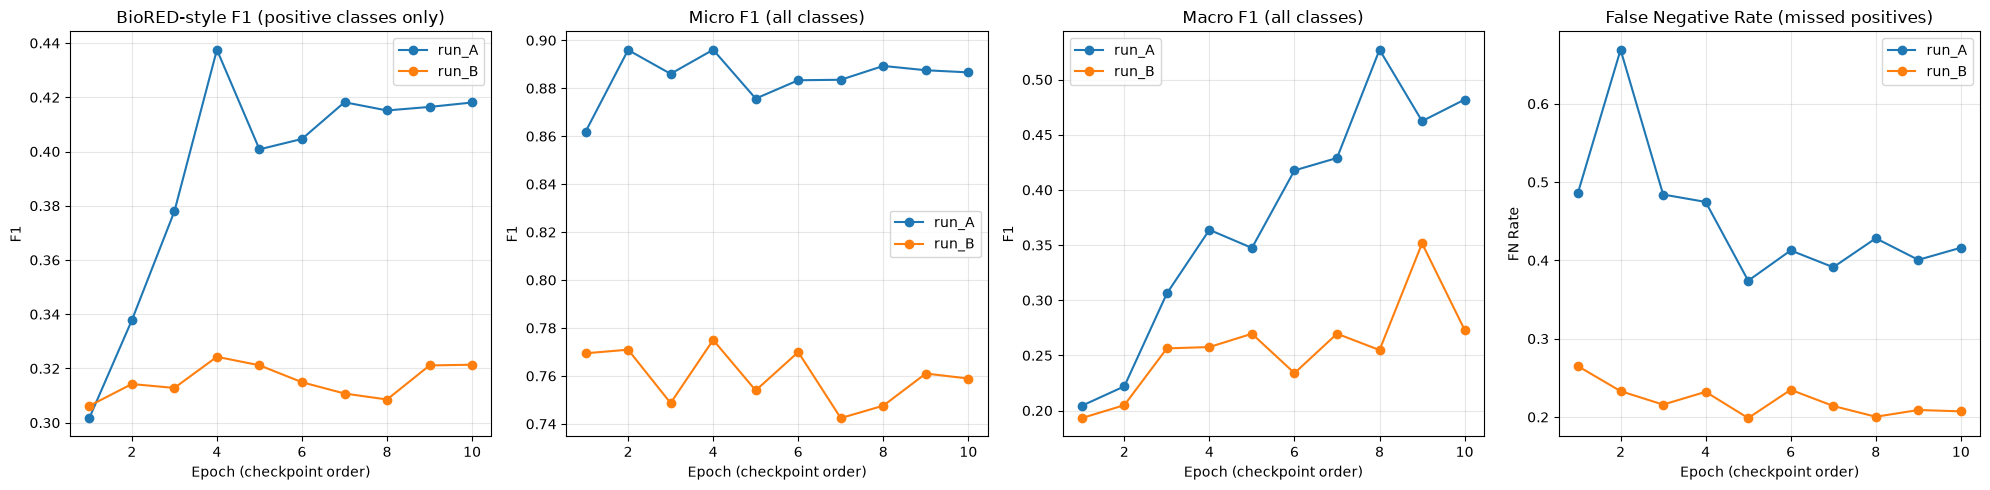

In [9]:
run_paths = {
    "run_A": "/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_14-17-35_BioRed_micro",
    "run_B": "/home/flabonte/LLMs_for_NEL/finetuning/relations-bert_NeuML-pubmedbert-base-embeddings_2026-07-13_13-24-43_BioRed_micro",
}

all_results = plot_checkpoints_comparison(
    run_paths=run_paths,
    dataset=tokenized_test_3,
    gold_col="relation_type",
    negative_label="NoRelation",
    data_collator=data_collator
)